# 06 · Validated call sets

**Question.** How do the call sets published as validated (one per aligner and variant caller, nine per center) overlap with each other and with the high-confidence truth set?

**Reviewer comment.** None.

**Reads.** The validated VCFs in `data/reference/validated_vcfs/` for the five centers LL, NC, EA, IL and FD (45 files, committed; parsing them takes about ten seconds) and the truth VCF `data/truth/hc_bed_filtered.recode.vcf`. The legacy caches in `data/derived/` are read only to check the parsed sets. It never reads `data/raw/`. The folder `NV` of the reference data holds nine more files and is not analysed, as in the legacy notebook: it is not one of the study's five centers.

**Sets.** A validated VCF becomes a set of `CHROM_POS_REF_ALT1` keys, with no FILTER test and no removal of indels (`swb.io.validated_sets`, as legacy). Each center's set is the intersection of its nine sets; the truth set is the SNV truth set of notebook 05.

**Produces** (`results/06_validated_vcfs/`):
- `tables/validated_sets.csv`: for each of the 45 validated VCFs, the variants, how many are SNVs and indels, and how many are in the truth set.
- `tables/center_sets.csv`: for each center, the size of the intersection and of the union of its nine sets, and the intersection's indels and overlap with the truth set.
- `tables/venn_regions.csv`: the exclusive regions of the six-set Venn diagram (truth set and the five center intersections).
- `figures/venn_comparison`: the pseudovenn and the venn of those six sets, as in the legacy figure, with the center colors of the other figures.

**Two legacy inconsistencies (D14, D15).** The count the legacy notebook printed as "EA Validated Set Count: 2388" is the LL intersection, not EA's. The section is titled "(without indels)", but the validated sets keep their indels. The intersections used in the Venn contain none (see `center_sets.csv`), so the figure is not affected, but the per-file sets and their union are. Both are reproduced as they are.

**Does not.** Remove the indels, use the folder `NV`, or compare the validated sets with the 480 pipeline runs.

## Imports

In [1]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import importlib.metadata
import os

import matplotlib.pyplot as plt
import pandas as pd

from swb import audit, config, io, metrics, viz

## Config

In [2]:
OUT = config.results_dir("06_validated_vcfs")
STAGE = audit.Stage(OUT / ".staging")

CENTERS = config.VALIDATED_CENTERS   # LL, NC, EA, IL, FD: the order of the legacy notebook
FILES_PER_CENTER = 9                 # 3 aligners x 3 callers
LEGACY_PRINTED_COUNT = 2388          # legacy cell 23 printed "EA Validated Set Count: 2388"

## Load + validate

In [3]:
truth = io.truth_set(str(config.TRUTH_VCF))
assert len(truth) > 0

files, validated = {}, {}
for center in CENTERS:
    folder = config.VALIDATED_VCFS / center
    assert folder.is_dir(), "missing " + folder.relative_to(config.REPO_ROOT).as_posix()
    files[center] = io.validated_vcf_files(str(folder))  # '._' and .DS_Store files are skipped
    assert len(files[center]) == FILES_PER_CENTER, (center, len(files[center]))
    validated[center] = io.validated_sets(files[center])
    assert set(validated[center]) == set(files[center]), "a validated VCF of {} is empty".format(center)
n_nv = len(io.real_files(str(config.VALIDATED_VCFS / "NV"), suffix=""))
print("{} validated VCFs parsed; {} truth variants; the folder NV ({} files) is not used".format(
    sum(len(f) for f in files.values()), len(truth), n_nv))

45 validated VCFs parsed; 1161 truth variants; the folder NV (9 files) is not used


## Analysis

In [4]:
rows = []
for center in CENTERS:
    for name, variants in sorted(validated[center].items()):
        aligner, caller = name.split("/")
        n_indel = sum(io.key_is_indel(v) for v in variants)
        rows.append((center, aligner, caller, len(variants), len(variants) - n_indel, n_indel, len(variants & truth)))
validated_table = pd.DataFrame(rows, columns=["center", "aligner", "caller", "n_variants", "n_snv", "n_indel", "n_in_truth"])
assert len(validated_table) == len(CENTERS) * FILES_PER_CENTER and (validated_table["n_variants"] > 0).all()

center_sets = {c: set.intersection(*validated[c].values()) for c in CENTERS}
center_table = pd.DataFrame([
    (c, len(center_sets[c]), len(set.union(*validated[c].values())), sum(io.key_is_indel(v) for v in center_sets[c]),
     len(center_sets[c] & truth)) for c in CENTERS],
    columns=["center", "n_intersection", "n_union", "n_intersection_indel", "n_intersection_in_truth"])
center_table

,center,n_intersection,n_union,n_intersection_indel,n_intersection_in_truth
0,LL,2388,125559,0,784
1,NC,2386,117562,0,781
2,EA,2464,125578,0,843
3,IL,2520,158701,0,879
4,FD,2450,203682,0,842


In [5]:
dataset = {"High confidence": truth}
dataset.update({"{} validated".format(c): center_sets[c] for c in CENTERS})
regions = metrics.venn_regions(dataset)
assert regions["size"].sum() == len(set().union(*dataset.values()))
regions.head(12)

,region,n_sets,size
0,LL validated + NC validated + EA validated + I...,5,1384
1,High confidence + LL validated + NC validated ...,6,627
2,High confidence,1,182
3,LL validated,1,90
4,FD validated,1,82
5,LL validated + NC validated + EA validated + I...,4,70
6,NC validated + EA validated + IL validated + F...,4,68
7,High confidence + NC validated + EA validated ...,5,47
8,High confidence + LL validated + EA validated ...,5,45
9,High confidence + LL validated + NC validated ...,5,30


## Save tables

Written to staging; moved to `results/06_validated_vcfs/` only if parity passes.

In [6]:
io.write_csv(validated_table, STAGE.path(OUT / "tables" / "validated_sets.csv"), sort_by=["center", "aligner", "caller"])
io.write_csv(center_table, STAGE.path(OUT / "tables" / "center_sets.csv"), sort_by="center")
io.write_csv(regions, STAGE.path(OUT / "tables" / "venn_regions.csv"), sort_by=["region"])

## Figures

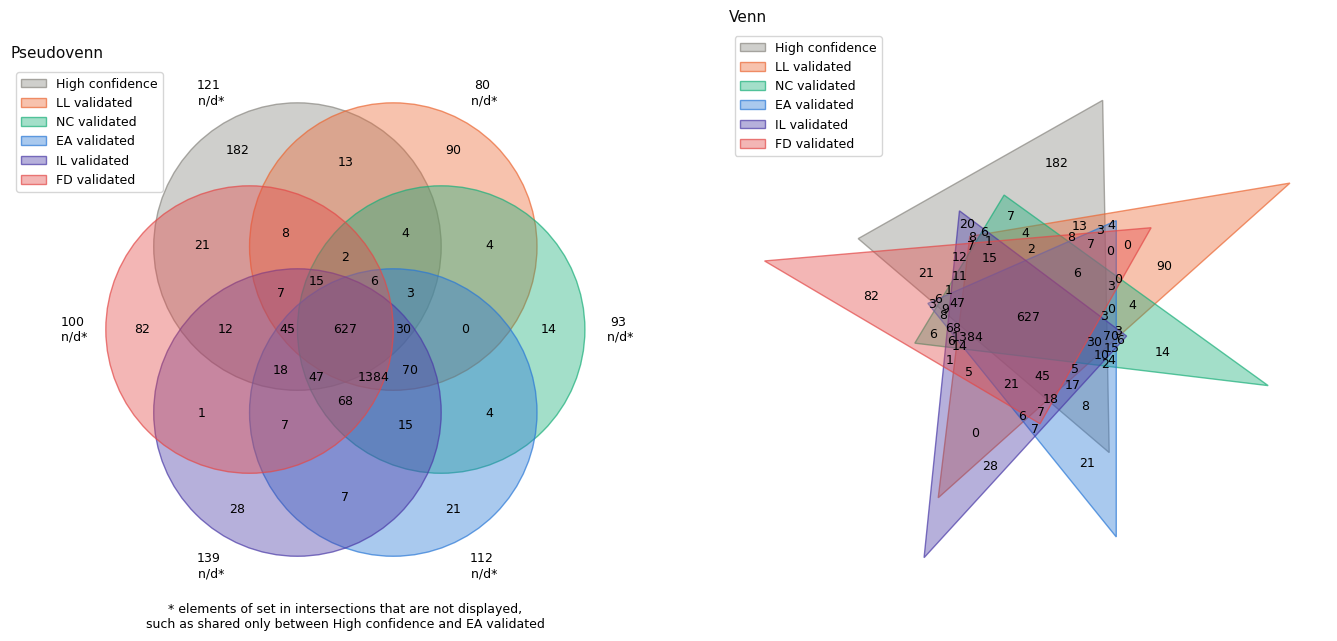

,region,n_sets,size
0,LL validated + NC validated + EA validated + I...,5,1384
1,High confidence + LL validated + NC validated ...,6,627
2,High confidence,1,182
3,LL validated,1,90
4,FD validated,1,82
5,LL validated + NC validated + EA validated + I...,4,70
6,NC validated + EA validated + IL validated + F...,4,68
7,High confidence + NC validated + EA validated ...,5,47
8,High confidence + LL validated + EA validated ...,5,45
9,High confidence + LL validated + NC validated ...,5,30


In [7]:
fig, axes = viz.venn_panels(dataset, [viz.TRUTH_COLOUR] + [viz.CENTER_BOX_COLOURS[c] for c in CENTERS])
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "venn_comparison"))
plt.show()
# Table view: the largest exclusive regions (all regions are in tables/venn_regions.csv)
regions.head(12)

## Parity check

Against the legacy files and the one value the legacy notebook printed:
- the 45 validated VCFs listed by the legacy file lists (`validated_vcfs_*_files.csv`) are the files found in the reference folder;
- the variant sets parsed from those VCFs equal the legacy sets (`validated_vcfs_*_sets.csv`), for every file;
- the count printed by legacy cell 23 is the LL intersection (D14).

The per-file counts, the Venn regions and the figure have no legacy numbers and are reported as not compared. Results are moved out of staging only if every check that ran passes.

In [8]:
parity = audit.Parity()

# File lists: the legacy path minus its prefix is the path relative to the reference folder
wrong_files = []
for center in CENTERS:
    legacy = pd.read_csv(config.LEGACY_VALIDATED_FILES[center])
    prefix = "vcf/validated_vcfs/{}/".format(center)
    legacy_paths = {str(k): v[len(prefix):] if v.startswith(prefix) else v for k, v in zip(legacy["testcase"], legacy["filepath"])}
    found = {k: os.path.relpath(p, str(config.VALIDATED_VCFS / center)) for k, p in files[center].items()}
    if legacy_paths != found:
        wrong_files.append(center)
parity.check("validated VCF file lists == legacy validated_vcfs_*_files.csv ({} centers x {} files)".format(
    len(CENTERS), FILES_PER_CENTER), not wrong_files, "differ: {}".format(wrong_files))

# Variant sets, file by file
different = []
for center in CENTERS:
    legacy_sets = io.load_sets(config.LEGACY_VALIDATED_SETS[center])
    different += ["{}/{}".format(center, k) for k in sorted(set(legacy_sets) | set(validated[center]))
                  if legacy_sets.get(k) != validated[center].get(k)]
parity.check("variant sets parsed from the reference VCFs == legacy validated_vcfs_*_sets.csv ({} files)".format(
    len(CENTERS) * FILES_PER_CENTER), not different, "{} differ: {}".format(len(different), different[:5]))

# The printed count (D14)
parity.check("legacy cell 23's printed count {} is the LL intersection".format(LEGACY_PRINTED_COUNT),
             len(center_sets["LL"]) == LEGACY_PRINTED_COUNT,
             "LL intersection {}".format(len(center_sets["LL"])))
parity.check("it is not the EA intersection, which its label claimed (D14)", len(center_sets["EA"]) != LEGACY_PRINTED_COUNT,
             "EA intersection {}".format(len(center_sets["EA"])))
parity.skip("validated_sets.csv, venn_regions.csv and the figure",
            "the legacy notebook printed one count and drew the figure; there are no other legacy numbers")

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (4 checks, 1 skipped)
PASS  validated VCF file lists == legacy validated_vcfs_*_files.csv (5 centers x 9 files)  [differ: []]
PASS  variant sets parsed from the reference VCFs == legacy validated_vcfs_*_sets.csv (45 files)  [0 differ: []]
PASS  legacy cell 23's printed count 2388 is the LL intersection  [LL intersection 2388]
PASS  it is not the EA intersection, which its label claimed (D14)  [EA intersection 2464]
SKIP  validated_sets.csv, venn_regions.csv and the figure  [the legacy notebook printed one count and drew the figure; there are no other legacy numbers]



## Audit summary

In [9]:
all_variants = set().union(*[s for c in CENTERS for s in validated[c].values()])
n_indel_all = sum(io.key_is_indel(v) for v in all_variants)
lines = [
    "validated VCFs: {} ({} centers x {}), parsed from {}; the folder NV ({} files) is not used".format(
        len(validated_table), len(CENTERS), FILES_PER_CENTER,
        config.VALIDATED_VCFS.relative_to(config.REPO_ROOT).as_posix(), n_nv),
    "parsed sets equal the legacy caches and file lists for every file",
    "truth set: {} SNVs".format(len(truth)),
    "",
    "intersection of each center's nine sets (size, of which indels, in the truth set):",
] + ["  {}: {}, {}, {}".format(r.center, r.n_intersection, r.n_intersection_indel, r.n_intersection_in_truth)
     for r in center_table.itertuples()] + [
    "",
    "D14: legacy cell 23 printed 'EA Validated Set Count: {}'; that is the LL intersection (EA: {})".format(
        LEGACY_PRINTED_COUNT, len(center_sets["EA"])),
    "D15: the validated sets keep their indels although the legacy section says 'without indels': {:,} of the {:,} distinct variants".format(
        n_indel_all, len(all_variants)),
    "  the center intersections used in the Venn hold {} indels in all".format(int(center_table["n_intersection_indel"].sum())),
    "not compared with legacy: validated_sets.csv, center_sets.csv, venn_regions.csv, the figure",
    "",
    "python {} | pandas {} | venn {}".format(sys.version.split()[0], pd.__version__, importlib.metadata.version("venn")),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

validated VCFs: 45 (5 centers x 9), parsed from data/reference/validated_vcfs; the folder NV (9 files) is not used
parsed sets equal the legacy caches and file lists for every file
truth set: 1161 SNVs

intersection of each center's nine sets (size, of which indels, in the truth set):
  LL: 2388, 0, 784
  NC: 2386, 0, 781
  EA: 2464, 0, 843
  IL: 2520, 0, 879
  FD: 2450, 0, 842

D14: legacy cell 23 printed 'EA Validated Set Count: 2388'; that is the LL intersection (EA: 2464)
D15: the validated sets keep their indels although the legacy section says 'without indels': 26,778 of the 575,670 distinct variants
  the center intersections used in the Venn hold 0 indels in all
not compared with legacy: validated_sets.csv, center_sets.csv, venn_regions.csv, the figure

python 3.8.12 | pandas 2.0.0 | venn 0.1.3
